# Applications of the TGDBEK to color images deblurring.

## 1.  Installation, imports, and utilities

In [1]:
!which python

/Users/jeremie/Documents/Papers/doc/.venv/bin/python


In [2]:
%%capture
!pip install -q git+https://github.com/jnlandu/tensor-tensor-toolbox-in-python

# %%capture
!pip install -q git+https://github.com/jnlandu/tensor-randomized-kaczmarz-algorithms

In [11]:
import io, gzip, requests
import torch
import scipy as sp
import scipy.sparse as ssp
from scipy.io import mmread
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt


import imageio.v3 as iio
from skimage import transform, img_as_float32
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

from tensor_toolbox.config import device, DTYPE

from tensor_toolbox.tensorLinalg import (
    bcirc,
    t_product,
    t_transpose,
    t_frobenius_norm,
    t_pinv_apply,
    unfold,
    fold
)

from trk_algorithms.utils import (
    rel_se, make_partitions,
    make_tensor_problem,
    display_results,
    plot_convergence,
)
from trk_algorithms.methods import (
    trek_algorithm,
    trebk_algorithm,
    tregbk_algorithm,
    treabk_algorithm
)

#### Reproducibility

In [12]:
seed = 1234
rng = np.random.default_rng(seed=seed)

### Utilities

In [13]:
def toeplitz_torch(c, r):
    """
    Toeplitz matrix with first column c and first row r.
    """
    c = c.flatten()
    r = r.flatten()
    m, n = c.numel(), r.numel()
    i = torch.arange(m, device=c.device)[:, None]
    j = torch.arange(n, device=c.device)[None, :]
    diff = i - j
    T = torch.where(diff >= 0, c[diff], r[-diff])
    return T

def make_toeplitz_gaussian_blur_matrix(N=200, sigma=3.0, band=25, device="cpu", dtype=torch.float32):
    """
    Build an NxN Toeplitz blur matrix A0
    from a truncated Gaussian kernel.
    Band controls blur strength; larger band => stronger blur.

    """
    t = torch.arange(N, device=device, dtype=dtype)
    z = torch.zeros(N, device=device, dtype=dtype)
    z[:band] = torch.exp(-(t[:band]**2) / (2 * sigma**2))

    # Toeplitz first column: [z0, z_{N-1}, ..., z1]
    c = torch.cat([z[:1], torch.flip(z[1:], dims=[0])], dim=0)
    A0 = toeplitz_torch(c, z)

    # Normalize rows to preserve brightness approximately
    A0 = (1/(sigma * torch.pi )) * A0 / (A0.sum(dim=1, keepdim=True) + 1e-12)
    return A0

def make_color_blur_tensor(N=200, p = 3, sigma=3.0, band=25, device="cpu", dtype=torch.float32):
    """
    Build A:(N,N,3) so that t-product applies the same A0 to EACH channel independently.
    We do this by setting A[:,:,0]=A0 and other frontal slices to 0.
    """
    A0 = make_toeplitz_gaussian_blur_matrix(N=N, sigma=sigma, band=band, device=device, dtype=dtype)
    # if p is None:
    # A0 = make_toeplitz_gaussian_blur_matrix(N=N, sigma=sigma, band=band, device=device, dtype=dtype)
    # A = torch.zeros((N, N, 3), device=device, dtype=dtype)
    # else:
    A = torch.zeros((N, N, p), device=device, dtype=dtype)

    A[:, :, 0] = A0

    return A

def load_color_image_as_tensor(path, N=200, device="cpu", dtype=torch.float32):
    """
    Load an RGB image, resize to NxN, return X_star:(N,N,3) in [0,1].
    """
    img = iio.imread(path)
    img = img_as_float32(img)  # -> float in [0,1] if possible
    print("Original image shape:", img.shape)
    img = transform.resize(img, (N, N), anti_aliasing=True, preserve_range=True).astype(np.float32)
    img = np.clip(img, 0.0, 1.0)

    if img.ndim == 2:
        # grayscale -> replicate channels
        img = np.stack([img, img, img], axis=-1)

    X_star = torch.from_numpy(img).to(device=device, dtype=dtype)  # (N,N,3)
    return X_star



def tensor_to_rgb_np(X):
    """
    X: (N,N,3) torch -> numpy image in [0,1]
    """
    Xnp = X.detach().cpu().numpy()
    Xnp = np.clip(Xnp, 0.0, 1.0)
    return Xnp

### Build the tensor system, display ground truth and noisy and blurred image.

The true image must be uploaded. You can replace the path `/content/flower.jpg` by the the path of your true image.


The original image we use has (960, 1280, 3) shape.  We reshape it  in order to have the size (200, 200, 3).


We generate the whole system on a `cpu` device. We can  set the device to `gpu` if needed.

1. Generate the tensor system.

In [65]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dtype  = torch.float32
seed =1234
N = 200
sigma_blur = 4.0
band = 32
noise_level = 1e-2

X_star = load_color_image_as_tensor("/content/flower.jpg", N=N, device=device, dtype=dtype)
A = make_color_blur_tensor(N=N, sigma=sigma_blur, band=band, device=device, dtype=dtype)

m, n, p = A.shape

Original image shape: (960, 1280, 3)


In [66]:
# System: B = A * X_* + epsilon
B_clean = t_product(A, X_star, device = device)                  # (N,N,3)

g = torch.Generator(device=B_clean.device)
g.manual_seed(seed)

E = torch.randn(B_clean.shape, device=B_clean.device, dtype=B_clean.dtype, generator=g)
E = E / (torch.linalg.norm(E) + 1e-12)

eps = noise_level * torch.linalg.norm(B_clean) * E

B = B_clean + eps

# Reference LS solution (dense t-pinv baseline)
X_ls = t_pinv_apply(A, B, rcond=1e-3)

2. Display the True image and its noisy and blurred version.


To measure the similarit between the original image and the blurry noisy version, we use `SSIM` and `PSNR`.

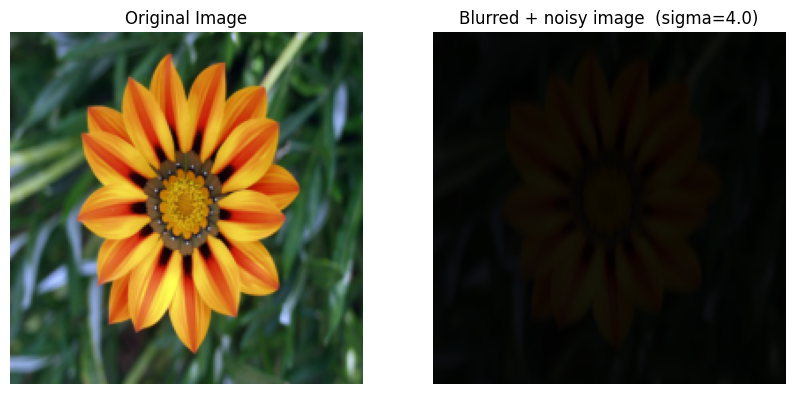

PSNR: 8.509910 dB, SSIM: 0.063190


In [67]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(X_star.clamp(0.0, 1.0).cpu().numpy())
axes[0].set_title("Original Image")
axes[0].axis('off')
axes[1].imshow(B.clamp(0.0, 1.0).cpu().numpy())
axes[1].set_title(f"Blurred + noisy image  (sigma={sigma_blur})")
axes[1].axis('off')
plt.show()

# Quality metrics
ps = psnr(X_star.cpu().numpy(), B.cpu().numpy(), data_range=1.0)
ss = ssim(X_star.cpu().numpy(), B.cpu().numpy(), channel_axis=-1, data_range=1.0)
print(f"PSNR: {ps:.6f} dB, SSIM: {ss:.6f}")

### Partitions

We set partitions for the methods TREBK, TREGBK, etc. The same partitions functions used for this experimenent, only the parameters `m` and `n` change.

In [17]:
# Partitions
#  1. Partitions for TREBK. It requires both row and col partitions. # In the paper, they used
#  Sequential generations with s= number of partitions, and tau = their size.
row_partitions_trebk_rec = make_partitions(m,  tau=10, sequential=True)
col_partitions_trebk_rec = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk_rec = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk_rec = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk_rec = make_partitions(n, tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk_rec), len(col_partitions_trebk_rec))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk_rec), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk_rec), len(col_partitions_treabk_rec))}")


Row and col  partitions TREBK: (20, 20)
Row and col  partitions TREGBK: (20, '_ ')
Row and col  partitions TREABK: (20, 20)


## 2. Tensor greedy double block extended Kaczmarz (TGDBEK)

In [21]:
def tgdbek_algorithm(A, B, T, x_ls, alpha=1.0, eta=0.9, tol=1e-5, rcond=1e-3):
    """
    Tensor greedy double block extended Kaczmarz algorithm.
    It solves the tensor inconsistent system AX=B+eps, where A,
    X, B,and eps are tensors.

    Parameters
    ----------
    A : (m, n, p) tensor.
    B: (m, k, p) tensor.
    T: int. max iterations.
    x_ls: (n, k, p) tensor reference (e.g. least-squares solution).
    eta: greedy threshold. Default .9.
    tol: tolerance. Default 1e-5.
    rcond: relative condition number for torch.linalg.pinv. Default 1e-3.

    Returns:
    --------
    (X_np, iters, res_hist, x_hist_np), runtime
    where X_np is the solution, iters is the number of iterations required to
    exceed the tolerance or  to exceed T, res_hist is the relative error and
    finally runtime is the required running time.

    """
    m, n, p = A.shape
    m_b, k, p_b = B.shape

    # Check dimensional compatibility
    assert (m == m_b) and (p == p_b), "A:(m,n,p), B:(m,k,p) required"

    # Initailize the device and the data type
    device = A.device
    dtype = A.dtype

    #  Initialize
    X = torch.zeros((n, k, p), dtype=dtype, device=device)
    Z = B.clone()

    #  Precompute Frob norm squares of tensor columns  and row slices.
    col_norms_sq = torch.sum(A**2, dim=(0, 2)) + 1e-12               # ||A_{:,j,:}||_F^2 over dims (0,2); shape (n,)
    row_norms_sq = torch.sum(A**2, dim=(1, 2)) + 1e-12               # ||A_{i,:,:}||_F^2 over dims (1,2); shape (m,)

    res_hist = []
    x_hist = []

    res_hist.append(float(rel_se(X, x_ls).item()))
    x_hist.append(X.clone())

    #  Start the loop
    t0 = time.time()
    with torch.no_grad():
        for iter_k in range(T):

            # ========== The Z-step ========:
            trans_A = t_transpose(A)                                 # (n, m, p)
            trans_A_Z = t_product(trans_A, Z)                        # (n, m, p) * (m, k, p) = (n, k, p)
            scores_z = torch.sum(trans_A_Z**2, dim=(1, 2)) / col_norms_sq

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.

            del trans_A                                             # to free memory
            del trans_A_Z                                           # to free memory

            eps_z = eta * torch.max(scores_z)
            U_k = torch.where(scores_z >= eps_z)[0]

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del eps_z
            del scores_z


            #  Block projection and update:
            A_U = A[:, U_k, :]                           # (m, |U|, p)
            W = t_pinv_apply(A_U, Z, rcond=rcond)        # (|U|, k, p) = (A_U)^dagger * Z
            Z = Z - alpha * t_product(A_U, W)            # (m, k, p)

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del W, A_U, U_k

            # =========================================================
            # X-step: corrected greedy set J_k (row-wise residual!)
            # =========================================================
            AX = t_product(A, X)                        # (m, k, p)
            R = B - Z - AX                              # (m, k, p)

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del AX

            scores_x = torch.sum(R**2, dim=(1, 2)) / row_norms_sq
            eps_x = eta * torch.max(scores_x)
            J_k = torch.where(scores_x >= eps_x)[0]

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.

            del R, scores_x, eps_x


            # Block projection and update
            A_J = A[J_k, :, :]                                             # (|J|, n, p)
            rhs = B[J_k, :, :] - Z[J_k, :, :] - t_product(A_J, X)          # (|J|, k, p)
            dX = t_pinv_apply(A_J, rhs, rcond=rcond)                       # (n, k, p)
            X = X + alpha *  dX

            # To Avoid cuda crash: free memory by deleting variables which are not used later in the loop.
            del A_J, rhs, dX

            #============ RSE and tolerance ======
            rse = rel_se(X, x_ls)
            res_hist.append(float(rse))
            x_hist.append(X.clone())

            if rse < tol:
                break

    runtime = time.time() - t0

    return (
        X.detach().cpu().numpy(),
        iter_k + 1,
        np.array(res_hist),
        np.array([x.detach().cpu().numpy() for x in x_hist])
    ), runtime


## 3. Run the experiments


To run the experiments, we put all the tensors on the cuda device if available.

In [20]:
tol = 1e-5
max_iter = 1000
eta = 0.5
delta = .7
# alpha_p =1.0
alpha=12.0

In [22]:

# Run  the experiments
print("------- running TREK -------")
(X_trek_rec, k_trek_rec, hist_trek_rec, x_hist_trek_rec), t_trek_rec = trek_algorithm(A,B,  x_ls=X_ls, T=max_iter, tol=tol)

print("------- running TREBEK -------")

(X_trebk_rec, k_trebk_rec, hist_trebk_rec, x_hist_trebk_rec), t_trebk_rec = trebk_algorithm(A,B,x_ls =X_ls,T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk_rec, col_partitions=col_partitions_trebk_rec)
print("------- running TREGBK -------")
(X_tregbk_rec, k_tregbk_rec, hist_tregbk_rec, x_hist_tregbk_rec), t_tregbk_rec  = tregbk_algorithm(A,B, x_ls =X_ls,T=max_iter, delta=delta, tol=tol, \
                                              row_partitions=row_partitions_tregbk_rec)

# (X_treabk_rec, k_treabk_rec, hist_treabk_rec, x_hist_treabk_rec), t_treabk_rec = treabk_algorithm(A,B, x_ls =X_ls,T=max_iter, alpha=alpha, tol=tol,\
#                                         row_partitions=row_partitions_treabk_rec, col_partitions=col_partitions_treabk_rec)

print("------- running TGDBEK -------")
(X_tgdbek_rec, k_tgdbek_rec, hist_tgdbek_rec, x_hist_tgdbek_rec), t_tgdbek_rec = tgdbek_algorithm(A,B, T=max_iter, x_ls=X_ls,eta=eta, tol=tol, rcond=1e-2)

------- running TREK -------
------- running TREBEK -------
------- running TREGBK -------
------- running TGDBEK -------


1. TREK: Display the reconstructed image vs the true image, and the associates metrics.

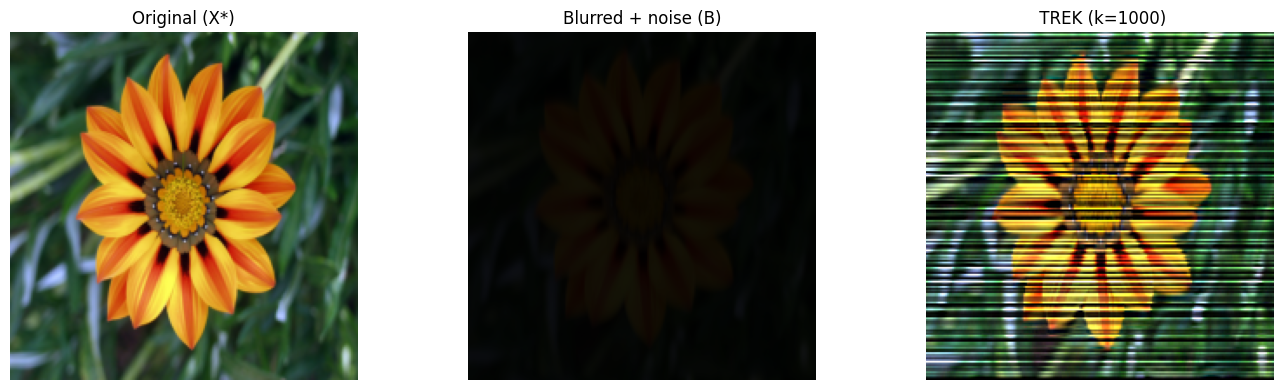

PSNR: 12.644778 dB, SSIM: 0.247785


In [23]:
X_trek_rec_np= torch.from_numpy(X_trek_rec).to(device=device, dtype=dtype)

orig = tensor_to_rgb_np(X_star)
blur = tensor_to_rgb_np(B)                               # blurred + noisy observation
rec_trek  = tensor_to_rgb_np(X_trek_rec_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(orig); axes[0].set_title("Original (X*)"); axes[0].axis("off")
axes[1].imshow(blur); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
axes[2].imshow(rec_trek);  axes[2].set_title(f" TREK (k={k_trek_rec})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Quality metrics
ps_trek = psnr(orig, rec_trek, data_range=1.0)
ss_trek = ssim(orig, rec_trek, channel_axis=-1, data_range=1.0)
print(f"PSNR: {ps_trek:.6f} dB, SSIM: {ss_trek:.6f}")

2. TREBK: Display the reconstructed image vs the true image, and the associates metrics.

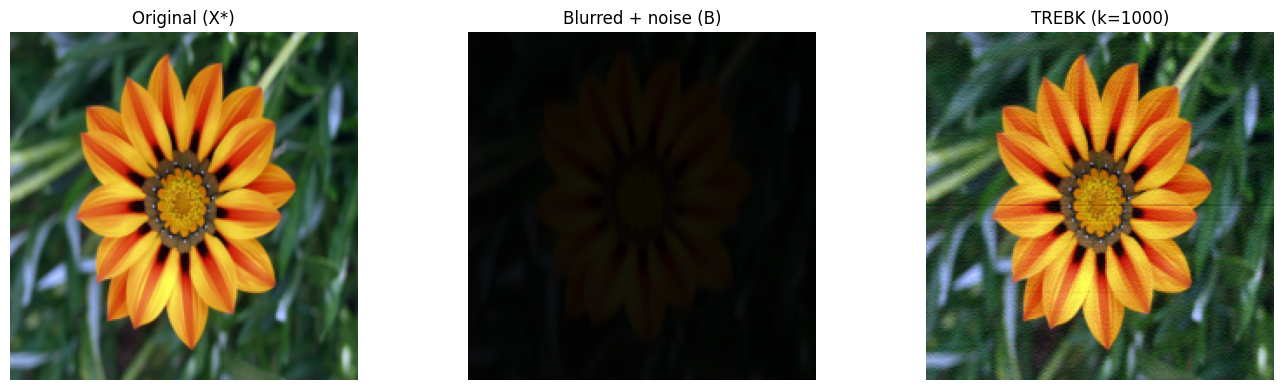

PSNR: 29.966828 dB, SSIM: 0.836602


In [25]:
# Convert to torch for metrics/display
X_trebk_rec_np= torch.from_numpy(X_trebk_rec).to(device=device, dtype=dtype)

orig = tensor_to_rgb_np(X_star)
blur = tensor_to_rgb_np(B)                       # blurred + noisy observation
rec_trebk   = tensor_to_rgb_np(X_trebk_rec_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(orig); axes[0].set_title("Original (X*)"); axes[0].axis("off")
axes[1].imshow(blur); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
axes[2].imshow(rec_trebk );  axes[2].set_title(f"TREBK (k={k_trebk_rec})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Quality metrics
ps = psnr(orig, rec_trebk , data_range=1.0)
ss = ssim(orig, rec_trebk , channel_axis=-1, data_range=1.0)
print(f"PSNR: {ps:.6f} dB, SSIM: {ss:.6f}")

3. TREGBK: Display the reconstructed image vs the true image, and the associates metrics.

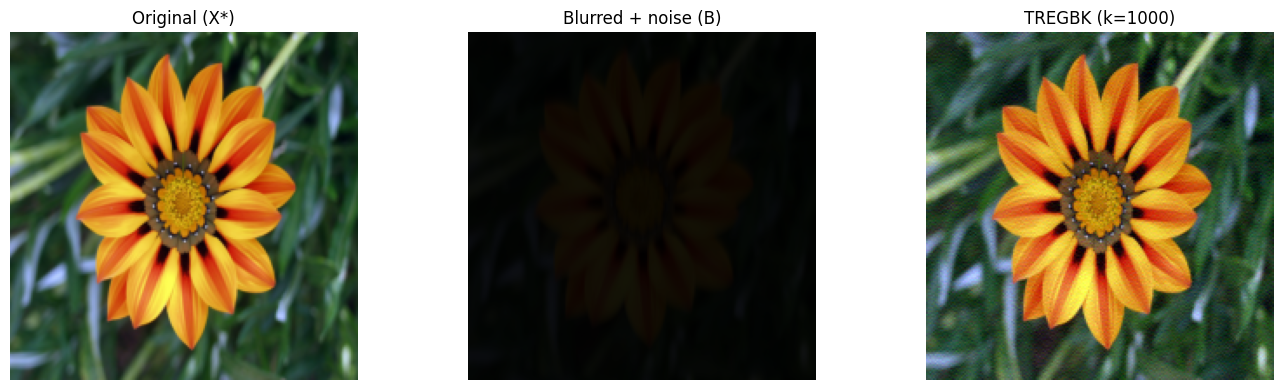

PSNR: 30.31382684 dB, SSIM: 0.84270531


In [26]:
# Convert to torch for metrics/display
X_tregbk_rec_np= torch.from_numpy(X_tregbk_rec).to(device=device, dtype=dtype)

orig = tensor_to_rgb_np(X_star)
blur = tensor_to_rgb_np(B)                        # blurred + noisy observation
rec_tregbk  = tensor_to_rgb_np(X_tregbk_rec_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(orig); axes[0].set_title("Original (X*)"); axes[0].axis("off")
axes[1].imshow(blur); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
axes[2].imshow(rec_tregbk);  axes[2].set_title(f"TREGBK (k={k_tregbk_rec})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Quality metrics
ps = psnr(orig, rec_tregbk, data_range=1.0)
ss = ssim(orig, rec_tregbk, channel_axis=-1, data_range=1.0)
print(f"PSNR: {ps:.8f} dB, SSIM: {ss:.8f}")

4. TREABK: Display the reconstructed image vs the true image, and the associates metrics.

In [ ]:
# # Convert to torch for metrics/display
# X_treabk_rec_np = torch.from_numpy(X_treabk_rec).to(device=device, dtype=dtype)

# orig = tensor_to_rgb_np(X_star)
# blur = tensor_to_rgb_np(B)       # blurred + noisy observation
# rec_treabk = tensor_to_rgb_np(X_treabk_rec_np)

# # fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# axes[0].imshow(orig); axes[0].set_title("Original (X*)"); axes[0].axis("off")
# axes[1].imshow(blur); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
# axes[2].imshow(rec_treabk);  axes[2].set_title(f"TREABK Restored (k={k_treabk_rec})"); axes[2].axis("off")
# plt.tight_layout()
# plt.show()

# # Quality metrics
# ps_treabk = psnr(orig, rec_treabk, data_range=1.0)
# ss_treabk = ssim(orig, rec_treabk, channel_axis=-1, data_range=1.0)
# print(f"PSNR: {ps_treabk:.6f} dB, SSIM: {ss_treabk:.6f}")

5. (Proposed) TGDBEK: Display the reconstructed image vs the true image, and the associates metrics.

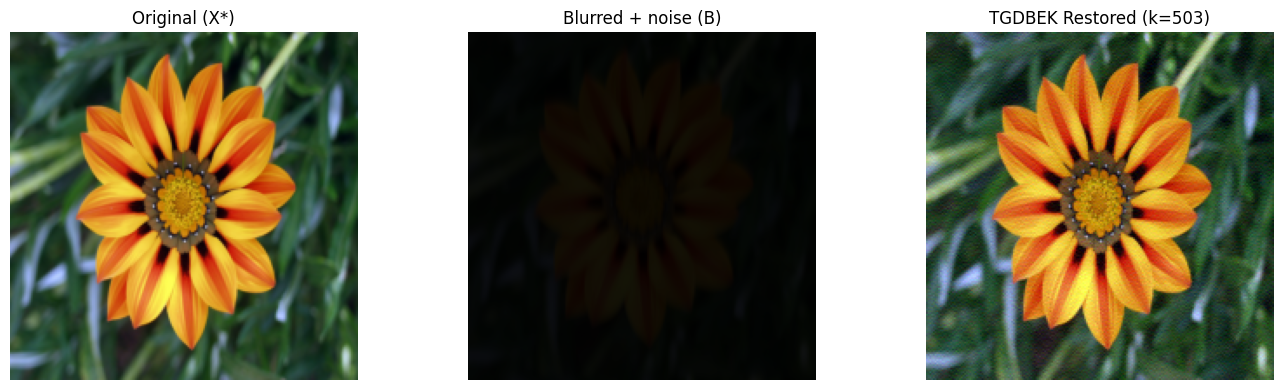

PSNR: 30.31304840 dB, SSIM: 0.84268421


In [27]:
# Convert to torch for metrics/display
X_tgdbek_rec_np = torch.from_numpy(X_tgdbek_rec).to(device=device, dtype=dtype)

orig = tensor_to_rgb_np(X_star)
blur = tensor_to_rgb_np(B)                        # blurred + noisy observation
rec_tgdbek  = tensor_to_rgb_np(X_tgdbek_rec_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(orig); axes[0].set_title("Original (X*)"); axes[0].axis("off")
axes[1].imshow(blur); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
axes[2].imshow(rec_tgdbek);  axes[2].set_title(f"TGDBEK Restored (k={k_tgdbek_rec})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Quality metrics
ps = psnr(orig, rec_tgdbek, data_range=1.0)
ss = ssim(orig, rec_tgdbek, channel_axis=-1, data_range=1.0)
print(f"PSNR: {ps:.8f} dB, SSIM: {ss:.8f}")

Compartive table and convergence plots.

In [28]:

results = [
  {'name': 'TREK', 'time': t_trek_rec, 'final_residual': hist_trek_rec[-1], 'iterations': k_trek_rec},
  {'name': 'TREBK', 'time': t_trebk_rec, 'final_residual': hist_trebk_rec[-1], 'iterations': k_trebk_rec},
  {'name': 'TREGBK', 'time': t_tregbk_rec, 'final_residual': hist_tregbk_rec[-1], 'iterations': k_tregbk_rec},
  # {'name': 'TREABK', 'time': t_treabk_rec, 'final_residual': hist_treabk_rec[-1], 'iterations': k_treabk_rec},
  {'name': 'TGDBEK', 'time': t_tgdbek_rec, 'final_residual': hist_tgdbek_rec[-1], 'iterations': k_tgdbek_rec},  ]

display_results(results)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
Method  Time (s)  Final Relative Residual  Iterations
  TREK  2.087535                 0.791908        1000
 TREBK  8.822373                 0.021765        1000
TREGBK  8.216356                 0.001267        1000
TGDBEK  6.006103                 0.000010         503


,Method,Time (s),Final Relative Residual,Iterations
0,TREK,2.087535,0.791908,1000
1,TREBK,8.822373,0.021765,1000
2,TREGBK,8.216356,0.001267,1000
3,TGDBEK,6.006103,0.000010,503


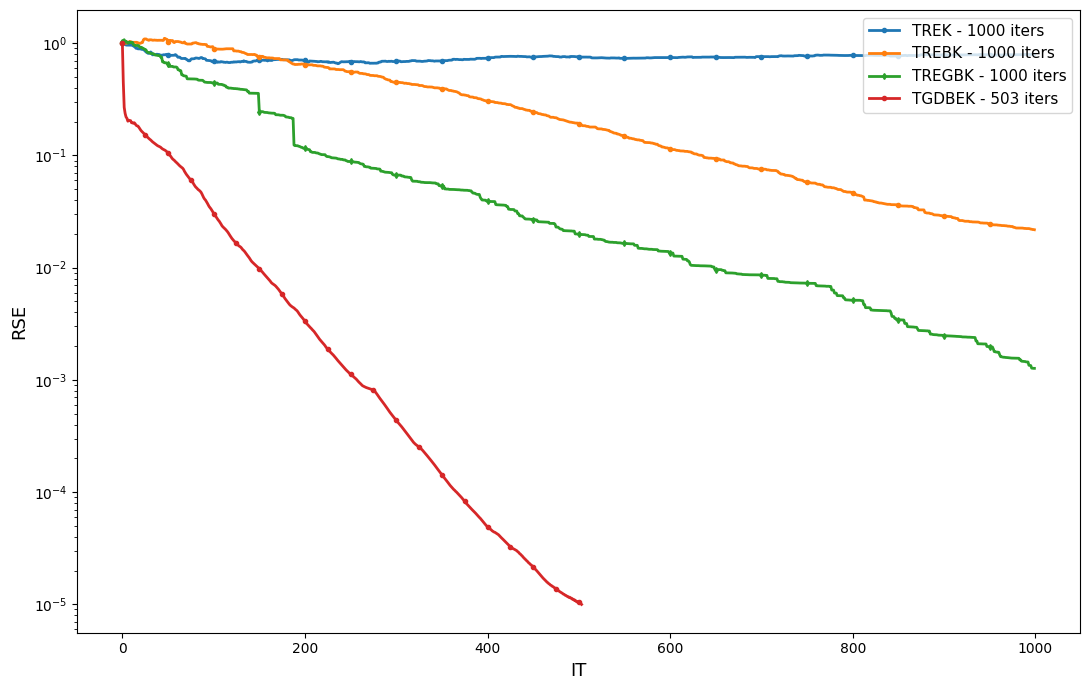

In [29]:
histories = [
  {'name': 'TREK', 'history': hist_trek_rec, 'iterations': k_trek_rec},
  {'name': 'TREBK', 'history': hist_trebk_rec, 'iterations': k_trebk_rec},
  {'name': 'TREGBK', 'history': hist_tregbk_rec, 'iterations': k_tregbk_rec, 'marker': 'd'},
  # {'name': 'TREABK', 'history': hist_treabk_rec, 'iterations': k_treabk_rec},
  {'name': 'TGDBEK', 'history': hist_tgdbek_rec, 'iterations': k_tgdbek_rec},
]
plot_convergence(histories)

# B. Gray image reconstruction.



In this part, we apply the proposed to reconstruct a gray image. We choose to use MRI images. The construction of the tensor system remains the same as in the part A. above.

### Imports

In [30]:
from skimage.transform import rotate
import matplotlib.pyplot as plt
from skimage import data, transform

### Utils. functions

In [31]:

def normalize01(x, eps=1e-12):
    x = x - x.min()
    return x / (x.max() + eps)

def show_frames(X, title=""):
    """X: (H,W,P) torch tensor (cpu or gpu) or numpy array"""
    if isinstance(X, np.ndarray):
        Xc = torch.from_numpy(X).float().cpu()
    else:
        Xc = X.detach().float().cpu()

    img = Xc[..., 0]
    img = normalize01(img)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

### Previsualize the MRI image.


We get MRI like images fddrom scikit-images, then build the system. We reshape the MRI image to (128, 128, 27).

In [32]:
device = torch.device("cuda") if torch.cuda.is_available else torch.device("cpu")
dtype  = torch.float32
seed =1234
N = 128
p = 27
sigma_blur = 4.0
band = 64
noise_level = 1e-3

X_star shape: (128, 128, 27)


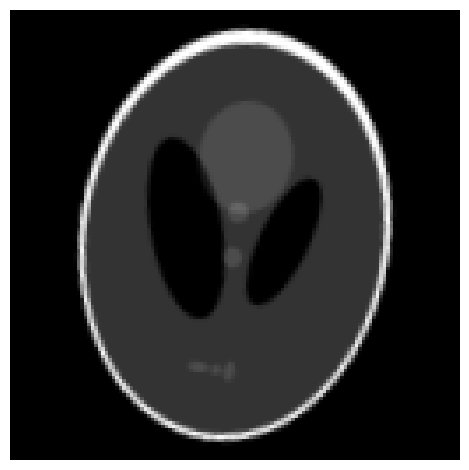

In [33]:
base = data.shepp_logan_phantom().astype(np.float32)  # 2D in [0,1]
base = transform.resize(base, (N, N), anti_aliasing=True).astype(np.float32)
base = np.clip(base, 0.0, 1.0)

vol = np.zeros((N, N, p), dtype=np.float32)
angles = np.linspace(-8, 8, p)  # small rotations
scales = 0.95 + 0.1 * np.sin(np.linspace(0, 2*np.pi, p))

for k in range(p):
    sl = rotate(base, angle=float(angles[k]), resize=False, mode="edge", preserve_range=True).astype(np.float32)
    sl = np.clip(scales[k] * sl, 0.0, 1.0)
    vol[:, :, k] = sl

X_star = torch.from_numpy(vol).to(device=device, dtype=dtype)

# X_star = make_mri_like_tensor(N=N, p=p, device=device, dtype=dtype)
print("X_star shape:", tuple(X_star.shape))
show_frames(X_star, title="Original")


### Build the system.

In [34]:
A = make_color_blur_tensor(N=N, p = p, sigma=sigma_blur, band=band, device=device, dtype=dtype)

m, n, p = A.shape

print(f"Shape of A: {A.shape},  Shape of X*: {X_star.shape}")



# System: B = A * X_* + epsilon
B_clean = t_product(A, X_star)                    # (N,N,p)

# print(A.shape)
g = torch.Generator(device=B_clean.device)
g.manual_seed(seed)

E = torch.randn(B_clean.shape, device=B_clean.device, dtype=B_clean.dtype, generator=g)
E = E / (torch.linalg.norm(E) + 1e-12)

eps = noise_level * torch.linalg.norm(B_clean) * E

B = B_clean + eps

# Reference LS solution (dense t-pinv baseline)
X_ls = t_pinv_apply(A, B, rcond=1e-3)             # (N,N,3)

Shape of A: torch.Size([128, 128, 27]),  Shape of X*: torch.Size([128, 128, 27])


Display the original image vs the blurred noisy image, and related SSIM and PSNR metics.

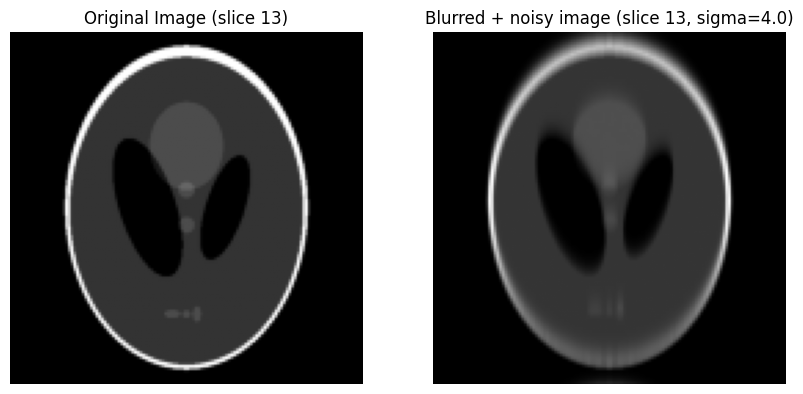

PSNR (slice 13): 13.624126 dB, SSIM (slice 13): 0.451225


In [40]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Select a central slice for display
central_slice_idx = X_star.shape[-1] // 2

axes[0].imshow(X_star[..., central_slice_idx].clamp(0.0, 1.0).cpu().numpy(), cmap='gray')
axes[0].set_title(f"Original Image (slice {central_slice_idx})")
axes[0].axis('off')

axes[1].imshow(B[..., central_slice_idx].clamp(0.0, 1.0).cpu().numpy(), cmap='gray')
axes[1].set_title(f"Blurred + noisy image (slice {central_slice_idx}, sigma={sigma_blur})")
axes[1].axis('off')
plt.show()

# Quality metrics for the displayed slice
ps = psnr(X_star[..., central_slice_idx].cpu().numpy(), B[..., central_slice_idx].cpu().numpy(), data_range=1.0)
ss = ssim(X_star[..., central_slice_idx].cpu().numpy(), B[..., central_slice_idx].cpu().numpy(), data_range=1.0)
print(f"PSNR (slice {central_slice_idx}): {ps:.6f} dB, SSIM (slice {central_slice_idx}): {ss:.6f}")

Partitions.

In [36]:
#  1. Partitions for TREBK. It requires both row and col partitions. # In the paper, they used
#  Sequential generations with s= number of partitions, and tau = their size.
row_partitions_trebk_rec = make_partitions(m,  tau=10, sequential=True)
col_partitions_trebk_rec = make_partitions(n, tau=10, sequential=True)

#  2. Partitions for TREGBK. It only requires partitioning the rows in s blocks
row_partitions_tregbk_rec = make_partitions(m, tau=10, sequential=True)

#  3. Partitions for TREABK:  The same block partitions style as 1.
row_partitions_treabk_rec = make_partitions(m, tau=10, sequential=True)
col_partitions_treabk_rec = make_partitions(n, tau=10, sequential=True)

print(f"Row and col  partitions TREBK: {(len(row_partitions_treabk_rec), len(col_partitions_trebk_rec))}")
print(f"Row and col  partitions TREGBK: {(len(row_partitions_tregbk_rec), "_ ")}")
print(f"Row and col  partitions TREABK: {(len(row_partitions_treabk_rec), len(col_partitions_treabk_rec))}")


Row and col  partitions TREBK: (13, 13)
Row and col  partitions TREGBK: (13, '_ ')
Row and col  partitions TREABK: (13, 13)


Run the experiments

In [37]:
# Run  the experiments
(X_trek_rec, k_trek_rec, hist_trek_rec, x_hist_trek_rec), t_trek_rec = trek_algorithm(A,B,  x_ls=X_ls, T=max_iter, tol=tol)


(X_trebk_rec, k_trebk_rec, hist_trebk_rec, x_hist_trebk_rec), t_trebk_rec = trebk_algorithm(A,B,x_ls =X_ls,T=max_iter, tol=tol,\
                                              row_partitions=row_partitions_trebk_rec, col_partitions=col_partitions_trebk_rec)

(X_tregbk_rec, k_tregbk_rec, hist_tregbk_rec, x_hist_tregbk_rec), t_tregbk_rec  = tregbk_algorithm(A,B, x_ls =X_ls,T=max_iter, delta=delta, tol=tol, \
                                              row_partitions=row_partitions_tregbk_rec)

(X_treabk_rec, k_treabk_rec, hist_treabk_rec, x_hist_treabk_rec), t_treabk_rec = treabk_algorithm(A,B, x_ls =X_ls,T=max_iter, alpha=alpha, tol=tol,\
                                        row_partitions=row_partitions_treabk_rec, col_partitions=col_partitions_treabk_rec)

(X_tgdbek_rec, k_tgdbek_rec, hist_tgdbek_rec, x_hist_tgdbek_rec), t_tgdbek_rec = tgdbek_algorithm(A,B, T=max_iter, x_ls=X_ls,eta=eta, tol=tol, rcond=1e-2)

1. TREK: Display original image vs reconstructed image, and related metrics.

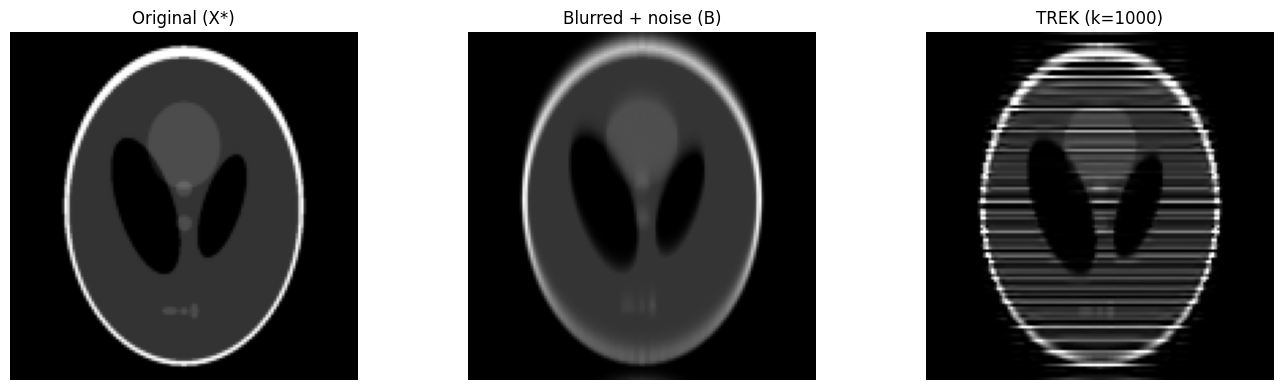

PSNR: 18.135240 dB, SSIM: 0.601815


In [50]:
# Convert to torch for metrics/display
X_trek_rec_np= torch.from_numpy(X_trek_rec).to(device=device, dtype=dtype)


orig = tensor_to_rgb_np(X_star)
blur = tensor_to_rgb_np(B)                            # blurred + noisy observation
rec  = tensor_to_rgb_np(X_trek_rec_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# Select a central slice for display
central_slice_idx = X_star.shape[-1] // 2

axes[0].imshow(orig[..., central_slice_idx], cmap='gray'); axes[0].set_title("Original (X*)"); axes[0].axis("off")
axes[1].imshow(blur[..., central_slice_idx], cmap='gray'); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
axes[2].imshow(rec[..., central_slice_idx], cmap='gray');  axes[2].set_title(f"TREK (k={k_trek_rec})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Quality metrics
ps = psnr(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
ss = ssim(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
print(f"PSNR: {ps:.6f} dB, SSIM: {ss:.6f}")

In [45]:
print(X_trek_rec_np.shape)
print(orig.shape)
print(rec.shape)

torch.Size([128, 128, 27])
(128, 128, 27)
(128, 128, 27)


2. TREBK: Display original image vs reconstructed image, and related metrics.

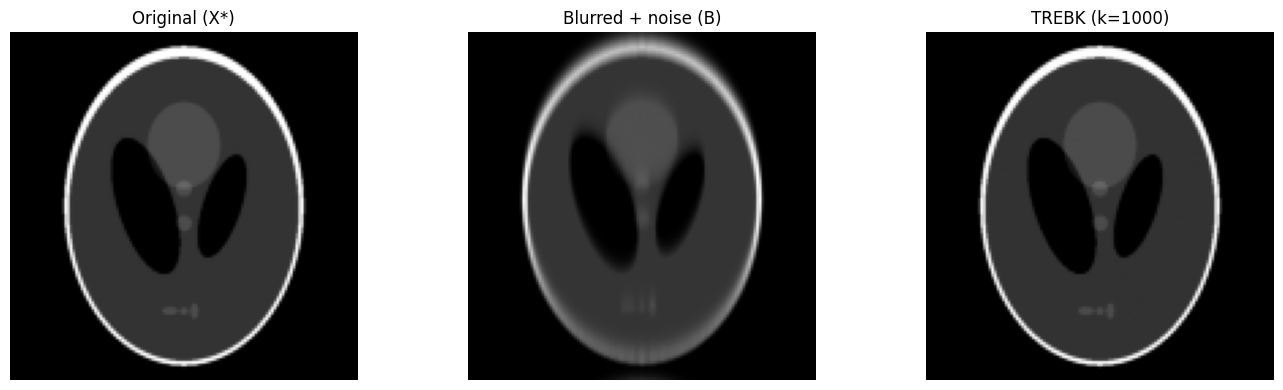

PSNR: 57.737170 dB, SSIM: 0.997613


In [52]:
# Convert to torch for metrics/display
X_trebk_rec_np= torch.from_numpy(X_trebk_rec).to(device=device, dtype=dtype)

orig = tensor_to_rgb_np(X_star)
blur = tensor_to_rgb_np(B)                         # blurred + noisy observation
rec  = tensor_to_rgb_np(X_trebk_rec_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# Select a central slice for display
central_slice_idx = X_star.shape[-1] // 2

axes[0].imshow(orig[..., central_slice_idx], cmap='gray'); axes[0].set_title("Original (X*)"); axes[0].axis("off")
axes[1].imshow(blur[..., central_slice_idx], cmap='gray'); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
axes[2].imshow(rec[..., central_slice_idx], cmap='gray');  axes[2].set_title(f"TREBK (k={k_trebk_rec})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Quality metrics
ps = psnr(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
ss = ssim(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
print(f"PSNR: {ps:.6f} dB, SSIM: {ss:.6f}")

3. TREGBK: Display original image vs reconstructed image, and related metrics.

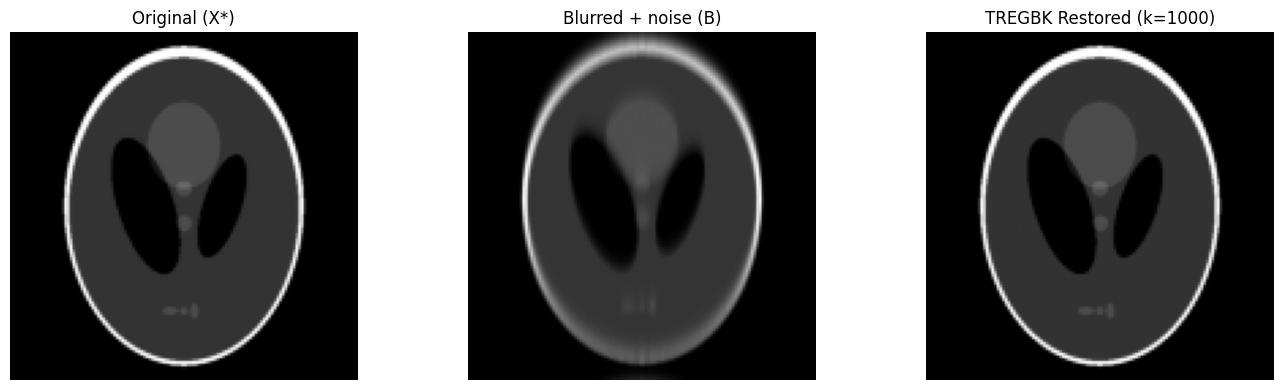

PSNR: 57.991105 dB, SSIM: 0.997630


In [54]:

# Convert to torch for metrics/display
X_tregbk_rec_np= torch.from_numpy(X_tregbk_rec).to(device=device, dtype=dtype)

orig = tensor_to_rgb_np(X_star)
blur = tensor_to_rgb_np(B)       # blurred + noisy observation
rec  = tensor_to_rgb_np(X_tregbk_rec_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# Select a central slice for display
central_slice_idx = X_star.shape[-1] // 2

axes[0].imshow(orig[..., central_slice_idx], cmap='gray'); axes[0].set_title("Original (X*)"); axes[0].axis("off")
axes[1].imshow(blur[..., central_slice_idx], cmap='gray'); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
axes[2].imshow(rec[..., central_slice_idx], cmap='gray');  axes[2].set_title(f"TREGBK Restored (k={k_tregbk_rec})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Quality metrics
ps = psnr(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
ss = ssim(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
print(f"PSNR: {ps:.6f} dB, SSIM: {ss:.6f}")

4. TREABK: Display original image vs reconstructed image, and related metrics.

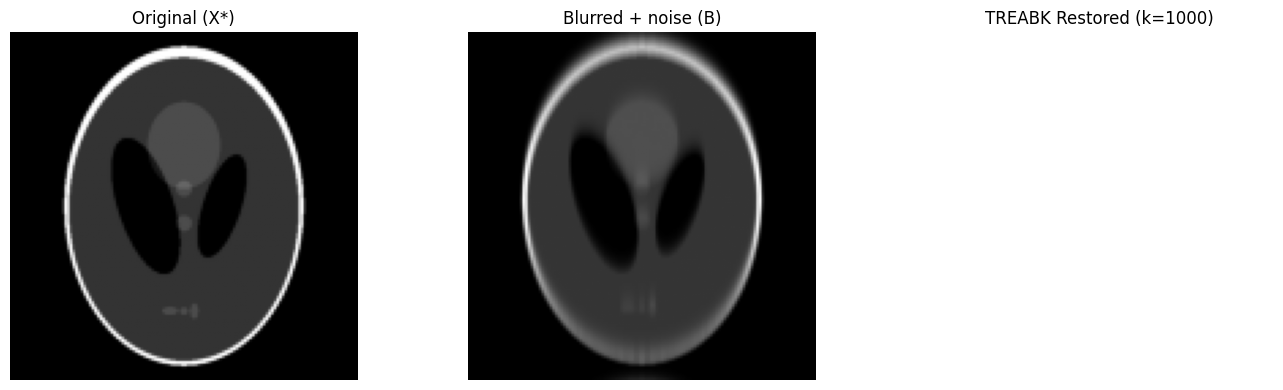

PSNR: nan dB, SSIM: nan


In [62]:

# Convert to torch for metrics/display
X_treabk_rec_np= torch.from_numpy(X_treabk_rec).to(device=device, dtype=dtype)

orig = tensor_to_rgb_np(X_star)
blur = tensor_to_rgb_np(B)       # blurred + noisy observation
rec  = tensor_to_rgb_np(X_treabk_rec_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# Select a central slice for display
central_slice_idx = X_star.shape[-1] // 2

axes[0].imshow(orig[..., central_slice_idx], cmap='gray'); axes[0].set_title("Original (X*)"); axes[0].axis("off")
axes[1].imshow(blur[..., central_slice_idx], cmap='gray'); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
axes[2].imshow(rec[..., central_slice_idx], cmap='gray');  axes[2].set_title(f"TREABK Restored (k={k_treabk_rec})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Quality metrics
ps = psnr(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
ss = ssim(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
print(f"PSNR: {ps:.6f} dB, SSIM: {ss:.6f}")

5. TGDBEK: Display original image vs reconstructed image, and related metrics.

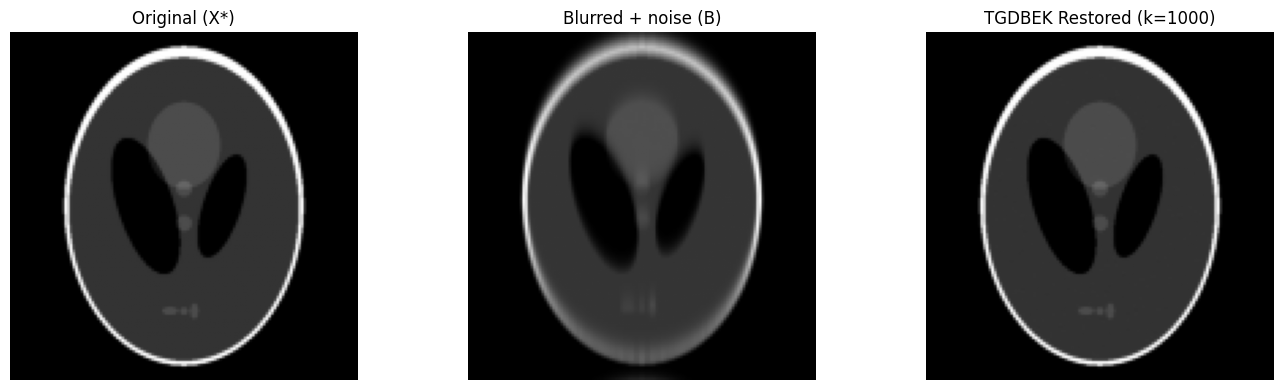

PSNR: 57.990740 dB, SSIM: 0.997630


In [63]:

# Convert to torch for metrics/display
X_tgdbek_rec_np= torch.from_numpy(X_tgdbek_rec).to(device=device, dtype=dtype)

orig = tensor_to_rgb_np(X_star)
blur = tensor_to_rgb_np(B)       # blurred + noisy observation
rec  = tensor_to_rgb_np(X_tgdbek_rec_np)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# Select a central slice for display
central_slice_idx = X_star.shape[-1] // 2

axes[0].imshow(orig[..., central_slice_idx], cmap='gray'); axes[0].set_title("Original (X*)"); axes[0].axis("off")
axes[1].imshow(blur[..., central_slice_idx], cmap='gray'); axes[1].set_title("Blurred + noise (B)"); axes[1].axis("off")
axes[2].imshow(rec[..., central_slice_idx], cmap='gray');  axes[2].set_title(f"TGDBEK Restored (k={k_tregbk_rec})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Quality metrics
ps = psnr(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
ss = ssim(orig[..., central_slice_idx], rec[..., central_slice_idx], data_range=1.0)
print(f"PSNR: {ps:.6f} dB, SSIM: {ss:.6f}")

# C. High-iteration color image deblurring (Example 4.4)

Same Gaussian blur model as Part A ($\sigma=4$, band$=32$) applied to a second $200\times200\times3$
test image (scikit-image `astronaut`), with noise level $a=10^{-1}$ and a maximum of $3000$
iterations. This stress-tests the long-run convergence regime and corresponds to Example 4.4
in the paper.

In [4]:
import os

# ---- Problem setup ----
device_c = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
dtype_c  = torch.float32
seed_c   = 1234

N_c           = 200
sigma_blur_c  = 4.0
band_c        = 32
noise_level_c = 1e-1  # higher noise: stress-tests extended Kaczmarz correction

# Second test image: astronaut (512x512x3 uint8), resize to N_c x N_c
img_c = data.astronaut().astype(np.float32) / 255.0
img_c = transform.resize(img_c, (N_c, N_c), anti_aliasing=True,
                         preserve_range=True).astype(np.float32)
img_c = np.clip(img_c, 0.0, 1.0)
X_star_c = torch.from_numpy(img_c).to(device=device_c, dtype=dtype_c)  # (N_c, N_c, 3)

A_c = make_color_blur_tensor(N=N_c, p=3, sigma=sigma_blur_c, band=band_c,
                              device=device_c, dtype=dtype_c)
m_c, n_c, p_c = A_c.shape

g_c = torch.Generator(device=device_c)
g_c.manual_seed(seed_c)
B_clean_c = t_product(A_c, X_star_c)
E_c = torch.randn(B_clean_c.shape, device=device_c, dtype=dtype_c, generator=g_c)
E_c = E_c / (torch.linalg.norm(E_c) + 1e-12)
B_c = B_clean_c + noise_level_c * torch.linalg.norm(B_clean_c) * E_c
X_ls_c = t_pinv_apply(A_c, B_c, rcond=1e-3)

print(f'A: {A_c.shape},  B: {B_c.shape},  X*: {X_star_c.shape}')

# Display original vs blurred+noisy
orig_c = tensor_to_rgb_np(X_star_c)
blur_c = tensor_to_rgb_np(B_c)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig_c); axes[0].set_title('Original (astronaut)'); axes[0].axis('off')
axes[1].imshow(np.clip(blur_c, 0, 1)); axes[1].set_title(f'Blurred + noisy (a={noise_level_c})')
axes[1].axis('off')
plt.tight_layout(); plt.show()

TREBK  partitions: 20 row, 20 col
TREGBK partitions: 20 row


In [5]:
# ---- Partitions (tau=10, same as Parts A and B) ----
row_partitions_trebk_hi  = make_partitions(m_c, tau=10, sequential=True)
col_partitions_trebk_hi  = make_partitions(n_c, tau=10, sequential=True)
row_partitions_tregbk_hi = make_partitions(m_c, tau=10, sequential=True)
print(f'TREBK  partitions: {len(row_partitions_trebk_hi)} row, {len(col_partitions_trebk_hi)} col')
print(f'TREGBK partitions: {len(row_partitions_tregbk_hi)} row')

------- running TREK -------
------- running TREBK -------
------- running TREGBK -------
------- running TGDBEK -------


In [6]:
# ---- Run experiments (max_iter=3000, tol=1e-5, eta=0.5) ----
tol_hi      = 1e-5
max_iter_hi = 3000
eta_hi      = 0.5
delta_hi    = 0.7

print('------- running TREK -------')
(X_trek_hi, k_trek_hi, hist_trek_hi, _), t_trek_hi = trek_algorithm(
    A_c, B_c, x_ls=X_ls_c, T=max_iter_hi, tol=tol_hi)

print('------- running TREBK -------')
(X_trebk_hi, k_trebk_hi, hist_trebk_hi, _), t_trebk_hi = trebk_algorithm(
    A_c, B_c, x_ls=X_ls_c, T=max_iter_hi, tol=tol_hi,
    row_partitions=row_partitions_trebk_hi,
    col_partitions=col_partitions_trebk_hi)

print('------- running TREGBK -------')
(X_tregbk_hi, k_tregbk_hi, hist_tregbk_hi, _), t_tregbk_hi = tregbk_algorithm(
    A_c, B_c, x_ls=X_ls_c, T=max_iter_hi, delta=delta_hi, tol=tol_hi,
    row_partitions=row_partitions_tregbk_hi)

print('------- running TGDBEK -------')
(X_tgdbek_hi, k_tgdbek_hi, hist_tgdbek_hi, _), t_tgdbek_hi = tgdbek_algorithm(
    A_c, B_c, T=max_iter_hi, x_ls=X_ls_c, eta=eta_hi, tol=tol_hi, rcond=1e-2)

BENCHMARK RESULTS - TENSOR KACZMARZ METHODS (Using T-Product)
Method  Time (s)  Final Relative Residual  Iterations
  TREK 10.735749                 0.719326        3000
 TREBK 21.711413                 0.000010        2363
TREGBK 31.565514                 0.000010        1730
TGDBEK 18.456029                 0.000010         502


In [7]:
# ---- Comparative table ----
results_hi = [
    {'name': 'TREK',   'time': t_trek_hi,   'final_residual': hist_trek_hi[-1],   'iterations': k_trek_hi},
    {'name': 'TREBK',  'time': t_trebk_hi,  'final_residual': hist_trebk_hi[-1],  'iterations': k_trebk_hi},
    {'name': 'TREGBK', 'time': t_tregbk_hi, 'final_residual': hist_tregbk_hi[-1], 'iterations': k_tregbk_hi},
    {'name': 'TGDBEK', 'time': t_tgdbek_hi, 'final_residual': hist_tgdbek_hi[-1], 'iterations': k_tgdbek_hi},
]
display_results(results_hi)

In [8]:
# ---- Convergence plot — save to main-folder/tests/ex2-plot.png ----
os.makedirs('main-folder/tests', exist_ok=True)

fig_conv, ax_conv = plt.subplots(figsize=(7, 4))
styles = [('TREK', '-', 'C0'), ('TREBK', '--', 'C1'),
          ('TREGBK', '-.', 'C2'), ('TGDBEK', '-', 'C3')]
for (name, ls, col), hist in zip(styles,
        [hist_trek_hi, hist_trebk_hi, hist_tregbk_hi, hist_tgdbek_hi]):
    ax_conv.semilogy(hist, linestyle=ls, color=col, label=name)
ax_conv.set_xlabel('Iteration'); ax_conv.set_ylabel('RSE')
ax_conv.legend(); ax_conv.grid(True, which='both', linestyle=':')
fig_conv.tight_layout()
fig_conv.savefig('main-folder/tests/ex2-plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: main-folder/tests/ex2-plot.png')


Method       IT         RSE    CPU(s)   PSNR(dB)    SSIM
----------------------------------------------------------
TREK       3000   7.193e-01    10.736      10.44  0.1898
TREBK      2363   9.929e-06    21.711      10.26  0.1589
TREGBK     1730   9.568e-06    31.566      10.26  0.1589
TGDBEK      502   9.987e-06    18.456      10.26  0.1589


In [ ]:
# ---- Per-method restored images — save to main-folder/tests/tests/ex2-fig{1..4}.png ----
os.makedirs('main-folder/tests/tests', exist_ok=True)

method_specs = [
    ('TREK',   X_trek_hi,   'ex2-fig1', k_trek_hi),
    ('TREBK',  X_trebk_hi,  'ex2-fig2', k_trebk_hi),
    ('TREGBK', X_tregbk_hi, 'ex2-fig3', k_tregbk_hi),
    ('TGDBEK', X_tgdbek_hi, 'ex2-fig4', k_tgdbek_hi),
]
orig_c = tensor_to_rgb_np(X_star_c)

for method_name, X_rec, fname, k_it in method_specs:
    X_t   = torch.from_numpy(X_rec).to(device=device_c, dtype=dtype_c)
    rec_c = tensor_to_rgb_np(X_t)
    ps = psnr(orig_c, rec_c, data_range=1.0)
    ss = ssim(orig_c, rec_c, channel_axis=-1, data_range=1.0)
    print(f'{method_name:8s}  IT={k_it:5d}  RSE={hist_trek_hi[-1] if method_name=="TREK" else hist_trebk_hi[-1] if method_name=="TREBK" else hist_tregbk_hi[-1] if method_name=="TREGBK" else hist_tgdbek_hi[-1]:.3e}'
          f'  PSNR={ps:.2f} dB  SSIM={ss:.4f}')
    fig_r, ax_r = plt.subplots(figsize=(4, 4))
    ax_r.imshow(np.clip(rec_c, 0, 1)); ax_r.axis('off')
    ax_r.set_title(f'{method_name} (IT={k_it})')
    fig_r.tight_layout()
    fig_r.savefig(f'main-folder/tests/tests/{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: main-folder/tests/tests/{fname}.png')